In [ ]:
import os
os.environ["JAX_PLATFORMS"] = "cpu" #Para usar j-wave en CPU y que no se queje por la versión de JAX

import matplotlib.pyplot as plt
import numpy as np

from skimage.metrics import peak_signal_noise_ratio
from skimage.metrics import structural_similarity
from scipy.stats import pearsonr

from jax import jit
from jax import numpy as jnp
from matplotlib import pyplot as plt

from jwave.geometry import TimeAxis
from jwave.geometry import Medium
from jwave.geometry import Domain
from jwave.geometry import Sensors, points_on_circle


from jwave import FourierSeries
from jwave.acoustics import simulate_wave_propagation
from jwave.geometry import *
from jwave.utils import show_field

import fbpinn_wave as fw
from fbpinn_wave import Wave2D

from fbpinns.analysis import FBPINN_solution
from fbpinns.analysis import load_model

from delayandsum import applyDAS

Este notebook analiza la extensión de un sinograma a partir de otro sinograma obtenido en un recinto más pequeño y para menor tiempo final.

In [2]:
domain = Domain((2500, 2500), (0.1/2500, 0.1/2500))
medium = Medium(domain=domain, sound_speed=1490.0, attenuation=0.0, pml_size=30.0)
time_axis = TimeAxis.from_medium(medium, cfl=0.3, t_end=100e-6)
print(f"El dominio espacial en x va de {domain.spatial_axis[0].min()} m a {domain.spatial_axis[1].max()} m")
print(f"El dominio espacial en y va de {domain.spatial_axis[1].min()} m a {domain.spatial_axis[1].max()} m")

El dominio espacial en x va de -0.04997999966144562 m a 0.04997999966144562 m
El dominio espacial en y va de -0.04997999966144562 m a 0.04997999966144562 m


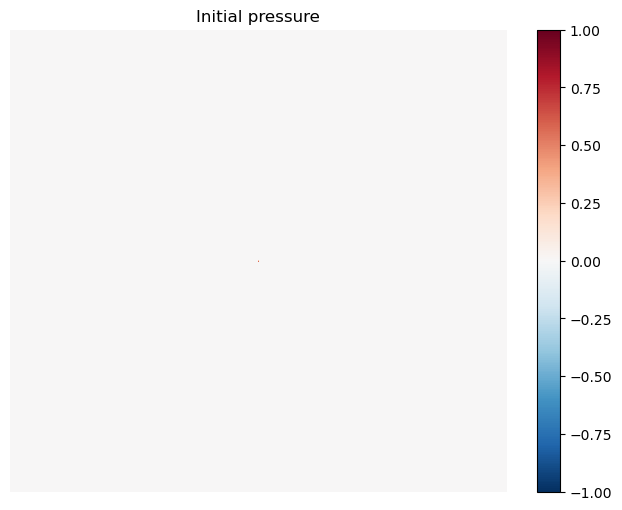

In [4]:

# Defining the initial pressure
N = domain.N

x, y = np.mgrid[0:N[0], 0:N[1]]
mui = jnp.array([-0, 0])/domain.dx[0] + np.array(N)/2
sigma = 1.5e-3/domain.dx[0]/20
p0 = jnp.exp(-0.5*(x-mui[0])**2/sigma**2) * jnp.exp(-0.5*(y-mui[1])**2/sigma**2)

p0 = FourierSeries(p0, domain)

show_field(p0)
plt.title("Initial pressure")
plt.show()

In [5]:
num_sensors = 64
rx = 45e-3
ri = rx/domain.dx[0]
xi, yi = points_on_circle(num_sensors, ri, (int(domain.N[0]/2), int(domain.N[0]/2)))
sensors_positions = (xi, yi)
sensors = Sensors(positions=sensors_positions)

In [ ]:
@jit
def compiled_simulator(medium, p0):
    a = simulate_wave_propagation(medium, time_axis, p0=p0, sensors=sensors)
    return a

p = compiled_simulator(medium, p0)
sensors_data = compiled_simulator(medium, p0)[..., 0]

Nt = int(time_axis.Nt)
dt = time_axis.dt


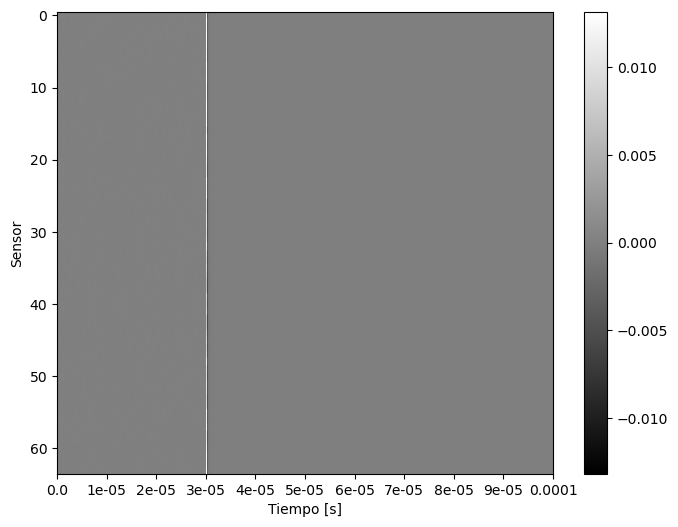

In [ ]:
dt = time_axis.dt

_field = FourierSeries(sensors_data.T, domain)
sinogram = _field.on_grid

plt.figure(figsize=(8,6))
maxval = jnp.amax(jnp.abs(sinogram))
plt.imshow(
    sinogram,
    cmap="gray",
    vmin=-maxval,
    vmax=maxval,
    interpolation="nearest",
    aspect="auto",
)
plt.colorbar()
num = 11
t_ticks = np.linspace(0, sinogram.shape[1], num=num)

plt.xticks(t_ticks, np.round(t_ticks*dt, decimals=5))
plt.title("Sinograma j-wave")
plt.xlabel("Tiempo [s]")
plt.ylabel("Sensor")
plt.show()

El modelo `pulse_2d_real_extended_fine2` se entrenó usando puntos de control, es decir, el aprendizaje es semi-supervisado ya que se simularon algunos puntos de la onda con j-wave, en los archivos `x_batch.npy` y `u_control.npy`. El modelo `pulse_2d_real_extended_fine1` es completamente no supervisado. Para ver los resultados de ese modelo, cambiar la linea:



```
const, model = load_model(run="test", i=200000, rootdir="pulse_2d_real_extended_fine2/results/")
```

Por:
```
const, model = load_model(run="test", i=200000, rootdir="pulse_2d_real_extended_fine1/results/")
```

In [ ]:
Wave2D()

ri = 15e-3/domain.dx[0] # El de la red
xi, yi = points_on_circle(num_sensors, ri, (int(domain.N[0]/2), int(domain.N[0]/2)))

t = time_axis.to_array()
t = np.linspace(0, 35e-6/20, 300) # El máximo de tiempo entrenado por la red
x = (np.array(xi)- domain.N[0]/2)*domain.dx[0]/20 # Escalo acá en vez de en el radio porque si lo hago antes la precisión del círcuo es mala 
y = (np.array(yi)- domain.N[1]/2)*domain.dx[0]/20

batch_shape = (len(x), t.shape[0])

xx, tt = np.meshgrid(x, t, indexing="xy")
yy, _ = np.meshgrid(y, t, indexing="xy")

const, model = load_model(run="test", i=200000, rootdir="pulse_2d_real_extended_fine2/results/")
_, all_params, _, active, _ = model

u = FBPINN_solution(const, all_params, active, np.c_[xx.T.flatten(), yy.T.flatten(), tt.T.flatten()]).reshape(batch_shape)


[INFO] 2025-12-03 15:42:07 - Loading model from:
pulse_2d_real_extended_fine2/results/models/test/model_00200000.jax
[INFO] 2025-12-03 15:42:09 - x_batch
[INFO] 2025-12-03 15:42:09 - (19200, 3), float64, ndarray
[INFO] 2025-12-03 15:42:09 - x_take
[INFO] 2025-12-03 15:42:09 - (342400, 3), float64, ndarray


El tiempo de simulación completo es 0 a 100 $\mu s$ y el dominio espacial cuadrado de 15 $mm$ de lado centrado en el origen, pero la simulación con FBPINNs está hecha hasta 35 $\mu s$ y en un cuadrado de 1.75 $mm$ de lado centrdo en el origen.

Se extiende el sinograma de FBPINNs para obtener el acorde al dominio real.

2.428e-08


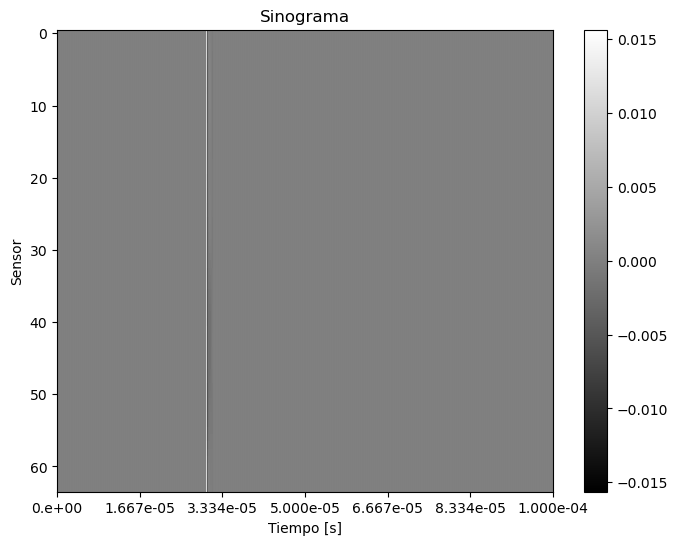

In [ ]:
sinogram_fbpinn, t_new = fw.extend_sinogram(u, 15e-3/20, 1490.0, 45e-3, t[1]-t[0], 100e-6, n_resample=sinogram.shape[1], smooth=False)

ec = (sinogram - sinogram_fbpinn)**2
ecm = np.format_float_scientific(np.mean(ec), precision=3)

plt.figure(figsize=(8,6))
maxval = jnp.amax(jnp.abs(sinogram_fbpinn))
plt.imshow(
    sinogram_fbpinn,
    cmap="gray",
    vmin=-maxval,
    vmax=maxval,
    interpolation="nearest",
    aspect="auto",
)
plt.colorbar()
num = 11
t_ticks = np.linspace(0, sinogram.shape[1], num=num)
t_string = list(range(t_ticks.shape[0]))
for i in range(t_ticks.shape[0]):
    t_string[i] = np.format_float_scientific((t_ticks[i]*(t_new[1]-t_new[0])), precision=3)
plt.xticks(t_ticks, t_string)
plt.title("Sinograma FBPINNs")
plt.xlabel("Tiempo [s]")
plt.ylabel("Sensor")
print(f"ECM = {ecm}")
plt.show()

La simulación de j-wave necesita una buena resolución de grilla para llegar a resultados buenos.

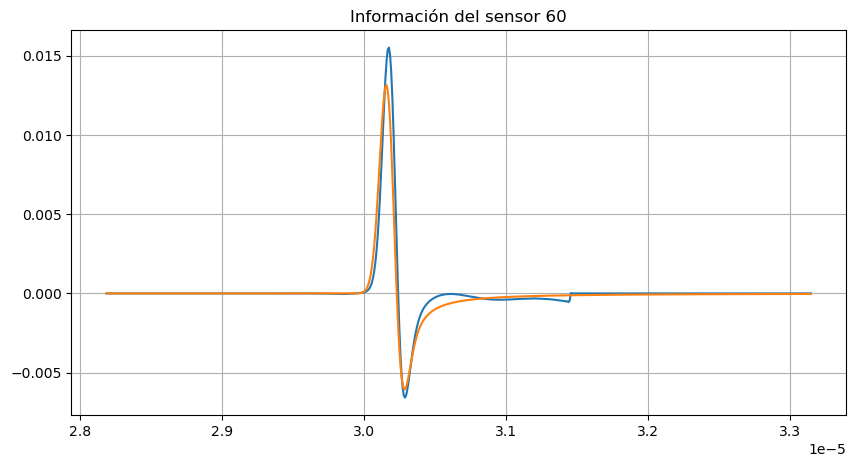

In [25]:
id = 60
start = 3500
end = 8300
sensor = sinogram[id,start:-end]
sensor_fbpinn = sinogram_fbpinn[id,start:-end]
t_axis = time_axis.to_array()

plt.figure(figsize=(10,5))

plt.subplot(1,1,1)
plt.title(f"Información del sensor {id}")
plt.plot(t_axis[start:-end], sensor_fbpinn)
plt.plot(t_axis[start:-end], sensor)
plt.grid()
plt.show()

## Figuras de mérito

In [ ]:
print("Para sinogramas:\n")
_ = fw.metricas_imagen(sinogram, sinogram_fbpinn)

Para sinogramas:

MSE = 2.428e-08
RMSE = 1.558e-04
PSNR = 42.64957752988762
SSIM = 0.9914921068313407
PCC = 0.9417943874881247


Para reconstrucciones con DAS:

MSE = 6.301e-04
RMSE = 2.510e-02
PSNR = 27.66535398535026
SSIM = 0.5931469837285885
PCC = 0.9547000786526915
Para reconstrucciones con DAS respecto a la presión original:

j-wave:
MSE = 1.787e-03
RMSE = 4.228e-02
PSNR = 22.806045486203118
SSIM = 0.20961889530385466
PCC = 0.9143743554512241

FBPINNs
MSE = 8.798e-04
RMSE = 2.966e-02
PSNR = 30.751379187731338
SSIM = 0.4205816482841598
PCC = 0.9581802435046745


c:\Users\matia\miniconda3\envs\tf\lib\site-packages\jax\_src\numpy\array_methods.py:68: UserWarning: Explicitly requested dtype <class 'numpy.float64'> requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/google/jax#current-gotchas for more.
  return lax_numpy.astype(arr, dtype, copy=copy, device=device)


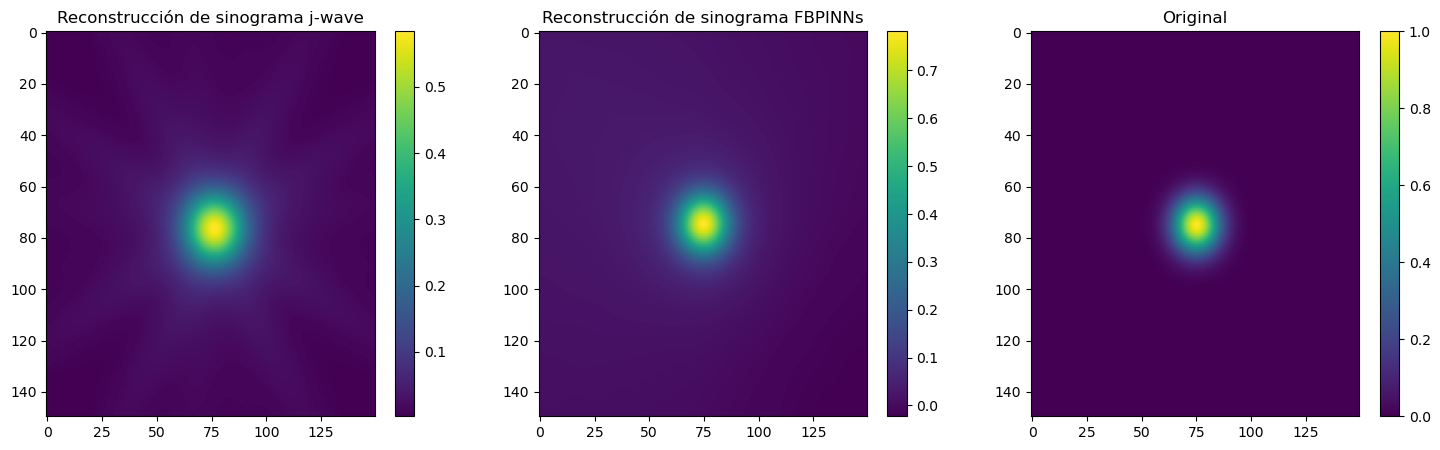

In [ ]:
Pjwave = applyDAS(sinogram.shape[0],sinogram.shape[1],10e-6,150,rx,360,1490,0,100e-6,sinogram).T
Pfbpinn = applyDAS(sinogram.shape[0],sinogram.shape[1],10e-6,150,rx,360,1490,0,100e-6,sinogram_fbpinn).T

N = [150,150]
dx = 10e-6

x, y = np.mgrid[0:N[0], 0:N[1]]
mui = jnp.array([-0, 0])/dx + np.array(N)/2
sigma = 1.5e-3/dx/20
p0 = jnp.exp(-0.5*(x-mui[0])**2/sigma**2) * jnp.exp(-0.5*(y-mui[1])**2/sigma**2)

plt.figure(figsize=(18,5))
plt.subplot(1,3,1)
plt.title('Reconstrucción de sinograma j-wave')
maxval = jnp.amax(jnp.abs(Pjwave))
plt.imshow(
    Pjwave,
    aspect="auto",
)
plt.colorbar()
plt.subplot(1,3,2)
plt.title('Reconstrucción de sinograma FBPINNs')
plt.imshow(
    Pfbpinn,
    aspect="auto",
)
plt.colorbar()
plt.subplot(1,3,3)
plt.title('Original')
plt.imshow(
    p0,
    aspect="auto",
)
plt.colorbar()

print("Para reconstrucciones con DAS:\n")
_ = fw.metricas_imagen(Pjwave, Pfbpinn)

print("\nPara reconstrucciones con DAS respecto a la presión original:\n")
print("j-wave:")
_ = fw.metricas_imagen(Pjwave, p0)
print("\nFBPINNs")
_ = fw.metricas_imagen(p0, Pfbpinn)